In [ ]:
### YOLOv8 Colab 학습 전체 코드
# 1. Ultralytics 설치
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 15.9 MB/s eta 0:00:00


In [ ]:
# ===============================================
# 🥬 YOLOv8 자동 라벨링 (Colab용)
# - batch inference + 병렬처리 + 자동 zip 압축
# ===============================================

import os, glob, zipfile
from concurrent.futures import ThreadPoolExecutor, as_completed
from ultralytics import YOLO

# ---- 경로 설정 ----
model_path = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/251011 양상추 seg 연습(2)/result/lettuce_yolov8n4/weights/best.pt"
image_root = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/병해충/무름병/20251001"

# ---- 모델 로드 ----
model = YOLO(model_path)

# ---- 이미지 경로 수집 (하위폴더 포함) ----
img_list = sorted(glob.glob(os.path.join(image_root, "**", "*.jpg"), recursive=True))
print(f"총 이미지: {len(img_list)}장")

# ---- 배치 크기 및 병렬 스레드 수 ----
BATCH_SIZE = 200    # 200장씩 나눔
MAX_WORKERS = 2     # Colab Pro에서 2~3 추천

# ---- 병렬 예측 함수 ----
def run_batch(batch_imgs, batch_idx):
    out_dir = f"/content/runs/segment/predict_{batch_idx}"
    results = model.predict(
        source=batch_imgs,
        imgsz=512,          # 🔹해상도 줄임 (512 or 640 권장)
        save_txt=True,
        save=True,
        save_conf=True,
        project="/content/runs/segment",
        name=f"predict_{batch_idx}",
        exist_ok=True
    )
    print(f"✅ Batch {batch_idx} 완료 ({len(batch_imgs)}장)")
    return out_dir

# ---- 병렬 실행 ----
futures = []
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    for i in range(0, len(img_list), BATCH_SIZE):
        batch = img_list[i:i+BATCH_SIZE]
        futures.append(executor.submit(run_batch, batch, i//BATCH_SIZE))

    for f in as_completed(futures):
        f.result()

print("🎉 모든 배치 완료!")

# ---- 결과 압축 (CVAT용) ----
zip_path = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/병해충/무름병/20251001/yolo_labels_for_cvat.zip"
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, _, files in os.walk("/content/runs/segment"):
        for file in files:
            if file.endswith(".txt"):
                file_path = os.path.join(root, file)
                arcname = os.path.relpath(file_path, "/content/runs/segment")
                zipf.write(file_path, arcname)
print(f"📦 압축 완료 → {zip_path}")


총 이미지: 794장

Ultralytics 8.3.223 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)

YOLOv8n-seg summary (fused): 85 layers, 3,258,259 parameters, 0 gradients, 11.3 GFLOPs
0: 384x512 2 Lettuce-plants, 2.3ms
1: 384x512 1 Lettuce-plant, 2.3ms
2: 384x512 1 Lettuce-plant, 2.3ms
3: 384x512 1 Lettuce-plant, 2.3ms
4: 384x512 1 Lettuce-plant, 2.3ms
5: 384x512 1 Lettuce-plant, 2.3ms
6: 384x512 1 Lettuce-plant, 2.3ms
7: 384x512 2 Lettuce-plants, 2.3ms
8: 384x512 1 Lettuce-plant, 2.3ms
9: 384x512 1 Lettuce-plant, 2.3ms
10: 384x512 3 Lettuce-plants, 2.3ms
11: 384x512 3 Lettuce-plants, 2.3ms
12: 384x512 2 Lettuce-plants, 2.3ms
13: 384x512 3 Lettuce-plants, 2.3ms
14: 384x512 5 Lettuce-plants, 2.3ms
15: 384x512 1 Lettuce-plant, 2.3ms
16: 384x512 1 Lettuce-plant, 2.3ms
17: 384x512 2 Lettuce-plants, 2.3ms
18: 384x512 2 Lettuce-plants, 2.3ms
19: 384x512 2 Lettuce-plants, 2.3ms
20: 384x512 2 Lettuce-plants, 2.3ms
21: 384x512 2 Lettuce-plants, 2.3ms
22: 384x512 1 Lettuce-plant, 2.3ms
23: 384x5

없는것만 비교해서 한번 더

In [ ]:
# ===============================================
# 🥬 YOLOv8 자동 라벨링 (라벨 없는 파일만 추론)
# ===============================================

import os, glob, zipfile
from concurrent.futures import ThreadPoolExecutor, as_completed
from ultralytics import YOLO

# ---- 경로 설정 ----
model_path = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/251011 양상추 seg 연습(2)/result/lettuce_yolov8n4/weights/best.pt"
image_root = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/병해충/무름병/20251001"
label_root = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/병해충/무름병/Labels_251001"

# ---- 모델 로드 ----
model = YOLO(model_path)

# ---- 이미지 및 라벨 목록 ----
img_ext = ('.jpg', '.jpeg', '.png')
imgs = sorted(glob.glob(os.path.join(image_root, "**", "*"), recursive=True))
imgs = [f for f in imgs if f.lower().endswith(img_ext)]
labels = [os.path.splitext(os.path.basename(x))[0] for x in glob.glob(os.path.join(label_root, "*.txt"))]

# ---- 라벨 없는 이미지만 추출 ----
target_imgs = [f for f in imgs if os.path.splitext(os.path.basename(f))[0] not in labels]
print(f"총 이미지 {len(imgs)}장 중 라벨 없는 파일: {len(target_imgs)}장")

if not target_imgs:
    print("🎉 모든 이미지에 라벨이 존재합니다. 종료합니다.")
else:
    # ---- 배치 크기 및 병렬 스레드 수 ----
    BATCH_SIZE = 200
    MAX_WORKERS = 2

    # ---- 배치 실행 함수 ----
    def run_batch(batch_imgs, batch_idx):
        out_dir = f"/content/runs/segment/predict_{batch_idx}"
        model.predict(
            source=batch_imgs,
            imgsz=512,      # 🔹리사이징 (512 or 640)
            save_txt=True,
            save=True,
            save_conf=True,
            project="/content/runs/segment",
            name=f"predict_{batch_idx}",
            exist_ok=True
        )
        print(f"✅ Batch {batch_idx} 완료 ({len(batch_imgs)}장)")
        return out_dir

    # ---- 병렬 실행 ----
    futures = []
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        for i in range(0, len(target_imgs), BATCH_SIZE):
            batch = target_imgs[i:i+BATCH_SIZE]
            futures.append(executor.submit(run_batch, batch, i//BATCH_SIZE))
        for f in as_completed(futures):
            f.result()

    print("🎯 모든 미라벨 이미지 자동라벨링 완료!")

    # ---- zip 압축 (CVAT용) ----
    zip_path = "/content/yolo_labels_new_only.zip"
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, _, files in os.walk("/content/runs/segment"):
            for file in files:
                if file.endswith(".txt"):
                    file_path = os.path.join(root, file)
                    arcname = os.path.relpath(file_path, "/content/runs/segment")
                    zipf.write(file_path, arcname)
    print(f"📦 압축 완료 → {zip_path}")


총 이미지 1989장 중 라벨 없는 파일: 1176장

Ultralytics 8.3.223 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)

YOLOv8n-seg summary (fused): 85 layers, 3,258,259 parameters, 0 gradients, 11.3 GFLOPs
0: 384x512 2 Lettuce-plants, 2.4ms
1: 384x512 3 Lettuce-plants, 2.4ms
2: 384x512 3 Lettuce-plants, 2.4ms
3: 384x512 4 Lettuce-plants, 2.4ms
4: 384x512 5 Lettuce-plants, 2.4ms
5: 384x512 1 Lettuce-plant, 2.4ms
6: 384x512 1 Lettuce-plant, 2.4ms
7: 384x512 1 Lettuce-plant, 2.4ms
8: 384x512 1 Lettuce-plant, 2.4ms
9: 384x512 1 Lettuce-plant, 2.4ms
10: 384x512 2 Lettuce-plants, 2.4ms
11: 384x512 1 Lettuce-plant, 2.4ms
12: 384x512 1 Lettuce-plant, 2.4ms
13: 384x512 1 Lettuce-plant, 2.4ms
14: 384x512 2 Lettuce-plants, 2.4ms
15: 384x512 2 Lettuce-plants, 2.4ms
16: 384x512 1 Lettuce-plant, 2.4ms
17: 384x512 1 Lettuce-plant, 2.4ms
18: 384x512 1 Lettuce-plant, 2.4ms
19: 384x512 1 Lettuce-plant, 2.4ms
20: 384x512 1 Lettuce-plant, 2.4ms
21: 384x512 1 Lettuce-plant, 2.4ms
22: 384x512 1 Lettuce-plant, 2

In [ ]:
import os

folder = r"/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/병해충/무름병/20251001"

for f in os.listdir(folder):
    if " (1)" in f:
        new_name = f.replace(" (1)", "")
        os.rename(os.path.join(folder, f), os.path.join(folder, new_name))
        print(f"✅ 이름 변경: {f} → {new_name}")


라벨링 잘됐는지 확인하기

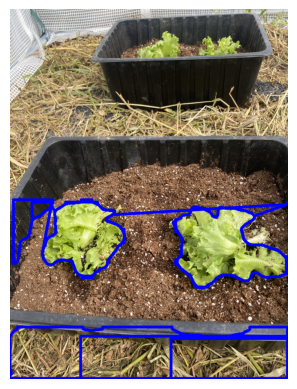

In [16]:
import cv2, numpy as np, matplotlib.pyplot as plt

img = cv2.imread('/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/병해충/무름병/20251001/IMG_4834.jpg')
h, w = img.shape[:2]

with open('/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/병해충/무름병/Labels_251001_fixed/IMG_4834.txt') as f:
    for line in f:
        vals = list(map(float, line.split()))
        # Check if the number of coordinate values is even before processing
        if len(vals[1:]) % 2 == 0:
            pts = np.array([(int(vals[i+1]*w), int(vals[i+2]*h)) for i in range(0, len(vals[1:]), 2)])
            cv2.polylines(img, [pts], isClosed=True, color=(255,0,0), thickness=30)
        else:
            print(f"Skipping line due to incomplete polygon: {line.strip()}")


plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [8]:
import os

path = '/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/병해충/무름병/Labels_251001_fixed'  # txt 폴더 경로

problem_files = set() # 문제가 있는 파일 이름을 저장할 set

for file in os.listdir(path):
    if file.endswith('.txt'):
        with open(os.path.join(path, file)) as f:
            for i, line in enumerate(f, 1):
                try:
                    vals = list(map(float, line.split()))
                    if (len(vals)-1) % 2 != 0:
                        print(f"{file} line {i}: 좌표 개수 {len(vals)-1} → 홀수 ⚠️")
                        problem_files.add(file) # 문제가 있는 파일 추가
                except ValueError:
                    print(f"Error in {file} line {i}: Could not convert to float. Line content: {line.strip()} ⚠️")
                    problem_files.add(file) # 문제가 있는 파일 추가

print(f"\n총 문제가 있는 파일 수: {len(problem_files)}개") # 문제가 있는 파일 총 개수 출력


총 문제가 있는 파일 수: 0개


In [7]:
# 수정 코드 그대로 복붙
import os

src = '/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/병해충/무름병/Labels_251001'          # 원본 txt 폴더
dst = '/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/병해충/무름병/Labels_251001_fixed'    # 수정본 폴더
os.makedirs(dst, exist_ok=True)

for file in os.listdir(src):
    if file.endswith('.txt'):
        lines_fixed = []
        with open(os.path.join(src, file)) as f:
            for line in f:
                vals = line.split()
                if len(vals) > 2:
                    # 홀수 좌표면 마지막 값 제거
                    if (len(vals)-1) % 2 != 0:
                        vals = vals[:-1]
                    lines_fixed.append(' '.join(vals))
        with open(os.path.join(dst, file), 'w') as out:
            out.write('\n'.join(lines_fixed))


원래 모델에서 함 보자

In [ ]:
/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/251011 양상추 seg 연습(2)/train/labels/20200320_03281110_jpg.rf.429bbf192167a3312b64548da5d093d9.txt

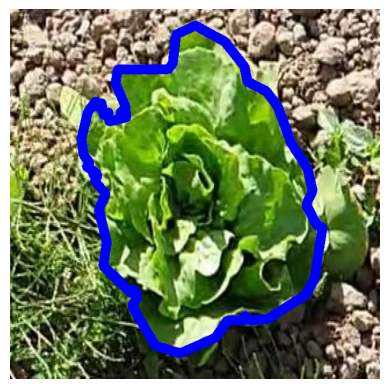

In [15]:
import cv2, numpy as np, matplotlib.pyplot as plt

img = cv2.imread('/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/251011 양상추 seg 연습(2)/train/images/20200320_03281110_jpg.rf.429bbf192167a3312b64548da5d093d9.jpg')
h, w = img.shape[:2]

with open('/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/251011 양상추 seg 연습(2)/train/labels/20200320_03281110_jpg.rf.429bbf192167a3312b64548da5d093d9.txt') as f:
    for line in f:
        vals = list(map(float, line.split()))
        # Check if the number of coordinate values is even before processing
        if len(vals[1:]) % 2 == 0:
            pts = np.array([(int(vals[i+1]*w), int(vals[i+2]*h)) for i in range(0, len(vals[1:]), 2)])
            cv2.polylines(img, [pts], isClosed=True, color=(255,0,0), thickness=15)
        else:
            print(f"Skipping line due to incomplete polygon: {line.strip()}")


plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

다시 해보자. 후처리 한걸로

In [2]:
import os, cv2, numpy as np
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor

# 📂 경로 설정
img_dir = '/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/병해충/무름병/20251001'       # 이미지 폴더
label_dir = '/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/병해충/무름병/Labels_251001_fixed'  # YOLO txt 폴더 (수정된 것)
out_dir = '/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/병해충/무름병/20251001_masks_cleaned'   # 결과 저장 폴더
os.makedirs(out_dir, exist_ok=True)

# 📏 마스크 정제 함수
def refine_mask(img_name):
    try:
        img_path = os.path.join(img_dir, img_name)
        label_path = os.path.join(label_dir, os.path.splitext(img_name)[0] + '.txt')
        if not os.path.exists(label_path):
            return

        # 이미지 로드 & 리사이즈
        img = cv2.imread(img_path)
        if img is None:
            return
        img = cv2.resize(img, (256, 256))
        h, w = img.shape[:2]
        mask = np.zeros((h, w), np.uint8)

        # txt → polygon 변환
        with open(label_path) as f:
            for line in f:
                vals = list(map(float, line.split()))
                if len(vals) < 6:
                    continue
                pts = np.array([(int(vals[i+1]*w), int(vals[i+2]*h))
                                for i in range(0, len(vals[1:]), 2)], np.int32)
                cv2.fillPoly(mask, [pts], 255)

        # 🔹 후처리: 경계 다듬기
        kernel = np.ones((5,5), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

        # 🔹 너무 큰 객체 제거 (화분 등)
        cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        clean = np.zeros_like(mask)
        for c in cnts:
            area = cv2.contourArea(c)
            if area < 0.5*h*w:
                cv2.drawContours(clean, [c], -1, 255, -1)

        # 🔹 mask 저장
        out_path = os.path.join(out_dir, os.path.splitext(img_name)[0] + '_mask.png')
        cv2.imwrite(out_path, clean)

    except Exception as e:
        print(f"❌ Error processing {img_name}: {e}")

# 🧵 병렬 처리 실행
img_list = [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
with ThreadPoolExecutor(max_workers=8) as executor:  # 💨 CPU 코어 수 맞춰 조절
    list(tqdm(executor.map(refine_mask, img_list), total=len(img_list)))

100%|██████████| 1989/1989 [08:46<00:00,  3.78it/s]
